# Notebook 02 — Temporal Behavior Drift Detection

> *It is not where the dog is that matters. It is the direction and speed of change.*

**Barkley Canine Cognition Lab · Research Demonstrator · Synthetic Data Only**

---

## Purpose

A single behavioral measurement, however extreme, can be noise — a bad night, a travel disruption, a sensor glitch.

**Drift is different.** Drift is directional. It persists. It accelerates.

This notebook explores three complementary approaches to detecting gradual individual-level behavioral drift from longitudinal data:

1. **Rolling Z-score** — how far is today's value from the individual's rolling baseline?
2. **CUSUM (Cumulative Sum Control Chart)** — a sequential detection method that accumulates small deviations until a threshold is crossed
3. **Multi-signal drift score** — combining signals across behavioral dimensions into a unified drift index

These methods are borrowed from statistical process control and time-series analysis. Their application here is **demonstrative and exploratory** — not a validated clinical pipeline.

---

> **Disclaimer:** All data is synthetic. Thresholds are illustrative. No clinical claims are made.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    "primary":  "#1A1A2E",
    "accent":   "#7B61FF",
    "signal":   "#FF4F6D",
    "stable":   "#00C9A7",
    "neutral":  "#B0B3C1",
    "bg":       "#F8F9FC",
    "warn":     "#FFB347",
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor':   COLORS['bg'],
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

df = pd.read_csv('../data/synthetic_doggraph_sample.csv', parse_dates=['date'])
df = df.sort_values(['dog_id', 'date']).reset_index(drop=True)
print(f"Loaded: {df.shape[0]:,} records · {df['dog_id'].nunique()} dogs")
print(f"Dogs with drift: {df[df['has_drift']]['dog_id'].nunique()}")
print(f"Dogs without drift: {df[~df['has_drift']]['dog_id'].nunique()}")


Loaded: 36,500 records · 100 dogs
Dogs with drift: 19
Dogs without drift: 81


## 1. Why Single-Point Snapshots Fail

Before building drift detectors, it's worth understanding why snapshot comparisons miss gradual drift.

The challenge: genuine behavioral drift unfolds over weeks and months. Daily behavioral noise can completely mask a real trend if you only look at individual days.

The solution: **temporal aggregation + trajectory analysis.**


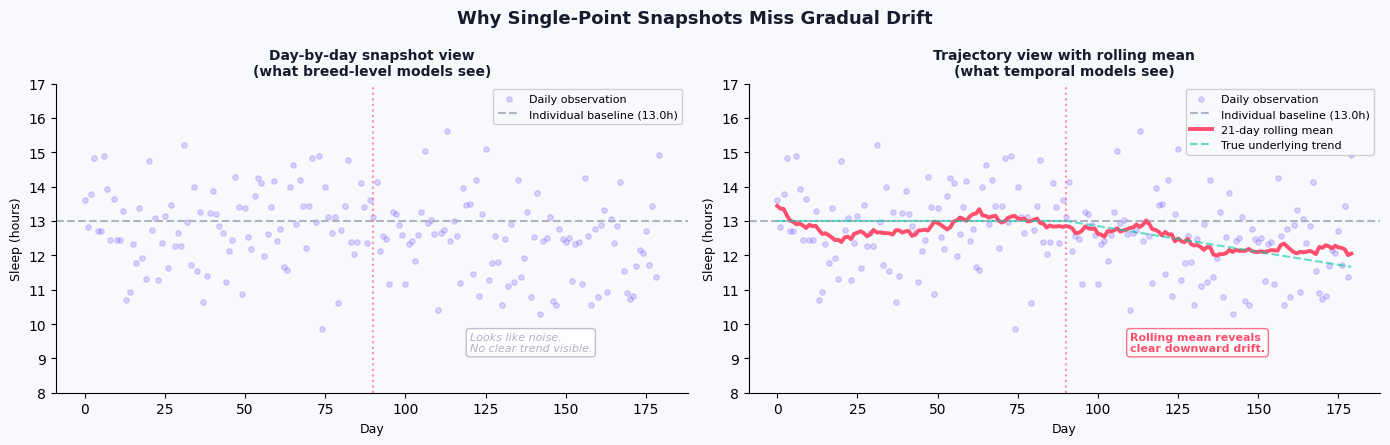

Key: 1.35h decline over 90 days is real, but invisible day-by-day.
Temporal aggregation is required to surface it.


In [2]:
# ── Noise masking a real trend ─────────────────────────────────────────────

np.random.seed(42)
days = np.arange(180)

# True underlying trajectory: stable then declining
true_baseline = 13.0
true_signal = np.where(days < 90,
                        true_baseline,
                        true_baseline - (days - 90) * 0.015)  # gradual 1.35h decline over 90 days

# Observed = true + daily noise
daily_noise = np.random.normal(0, 1.2, 180)
observed    = true_signal + daily_noise

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Why Single-Point Snapshots Miss Gradual Drift",
             fontsize=13, fontweight='bold', color=COLORS['primary'])

for i, (ax, title, show_trend) in enumerate(zip(
    axes,
    ["Day-by-day snapshot view\n(what breed-level models see)",
     "Trajectory view with rolling mean\n(what temporal models see)"],
    [False, True]
)):
    ax.set_facecolor(COLORS['bg'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.scatter(days, observed, color=COLORS['accent'], alpha=0.25, s=15, label='Daily observation')
    ax.axhline(true_baseline, color=COLORS['neutral'], linewidth=1.5,
               linestyle='--', label=f'Individual baseline ({true_baseline}h)')
    ax.axvline(90, color=COLORS['signal'], linewidth=1.5, linestyle=':', alpha=0.6)

    if show_trend:
        series = pd.Series(observed)
        rolling = series.rolling(21, center=True, min_periods=7).mean()
        ax.plot(days, rolling.values, color=COLORS['signal'], linewidth=2.8,
                label='21-day rolling mean')
        ax.plot(days, true_signal, color=COLORS['stable'], linewidth=1.5,
                linestyle='--', alpha=0.6, label='True underlying trend')

    ax.set_title(title, fontsize=10, fontweight='bold', color=COLORS['primary'])
    ax.set_xlabel('Day', fontsize=9)
    ax.set_ylabel('Sleep (hours)', fontsize=9)
    ax.set_ylim(8, 17)
    ax.legend(fontsize=8, framealpha=0.9)

    if not show_trend:
        ax.text(120, 9.2, 'Looks like noise.\nNo clear trend visible.', fontsize=8,
                color=COLORS['neutral'], style='italic',
                bbox=dict(boxstyle='round', fc='white', ec=COLORS['neutral'], alpha=0.8))
    else:
        ax.text(110, 9.2, 'Rolling mean reveals\nclear downward drift.', fontsize=8,
                color=COLORS['signal'], fontweight='bold',
                bbox=dict(boxstyle='round', fc='white', ec=COLORS['signal'], alpha=0.8))

plt.tight_layout()
plt.savefig('../figures/snapshot_vs_trajectory.png', dpi=130, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print("Key: 1.35h decline over 90 days is real, but invisible day-by-day.")
print("Temporal aggregation is required to surface it.")


## 2. Rolling Z-Score: How Far Is Today From the Individual's Own History?

The rolling Z-score is the simplest temporal anomaly detector. For each day, it asks:

> *How many standard deviations is today's value from the recent rolling mean?*

Unlike a breed Z-score (which compares to a population), this is purely **individual-referential**.

**Method:**
- Establish a stable baseline window (months 1–5)
- Compute a forward-rolling mean and standard deviation (21-day window)
- Z-score = (today - rolling_mean) / rolling_std
- Flag days where |Z| > threshold (we use 2.0 as an illustrative value)

This is a standard approach in time-series monitoring, adapted here for individual behavioral data.


In [3]:
# ── Rolling Z-score implementation ────────────────────────────────────────

def compute_rolling_zscore(dog_series, baseline_window_days=150, rolling_window=21):
    """
    Compute individual rolling Z-score for a behavioral signal.
    
    Parameters:
        dog_series: pd.Series with DatetimeIndex, daily behavioral values
        baseline_window_days: number of days used to establish stable baseline
        rolling_window: days for rolling statistics
    
    Returns:
        DataFrame with rolling mean, std, z-score
    """
    dog_series = dog_series.sort_index().dropna()
    
    # Baseline stats (first N days)
    baseline_cutoff = dog_series.index[0] + pd.Timedelta(days=baseline_window_days)
    baseline_data   = dog_series[dog_series.index < baseline_cutoff]
    baseline_mean   = baseline_data.mean()
    baseline_std    = baseline_data.std()
    
    # Rolling statistics
    rolling_mean = dog_series.rolling(f'{rolling_window}D', min_periods=7).mean()
    rolling_std  = dog_series.rolling(f'{rolling_window}D', min_periods=7).std().clip(lower=0.2)
    
    # Z-score against baseline
    z_score = (rolling_mean - baseline_mean) / baseline_std
    
    return pd.DataFrame({
        'value':        dog_series,
        'rolling_mean': rolling_mean,
        'rolling_std':  rolling_std,
        'z_score':      z_score,
        'baseline_mean': baseline_mean,
        'baseline_std':  baseline_std,
    })

# Apply to a drifting dog and a stable dog
drift_dogs  = df[df['has_drift']]['dog_id'].unique()
stable_dogs = df[~df['has_drift']]['dog_id'].unique()

dog_drift  = df[df['dog_id'] == drift_dogs[0]].set_index('date')
dog_stable = df[df['dog_id'] == stable_dogs[0]].set_index('date')

# Focus on sleep_hours, filter missing
zs_drift  = compute_rolling_zscore(dog_drift[~dog_drift['data_missing']]['sleep_hours'])
zs_stable = compute_rolling_zscore(dog_stable[~dog_stable['data_missing']]['sleep_hours'])

print("Rolling Z-score computed.")
print(f"Drifting dog — peak |Z|: {zs_drift['z_score'].abs().max():.2f}")
print(f"Stable dog   — peak |Z|: {zs_stable['z_score'].abs().max():.2f}")


Rolling Z-score computed.
Drifting dog — peak |Z|: 1.18
Stable dog   — peak |Z|: 0.55


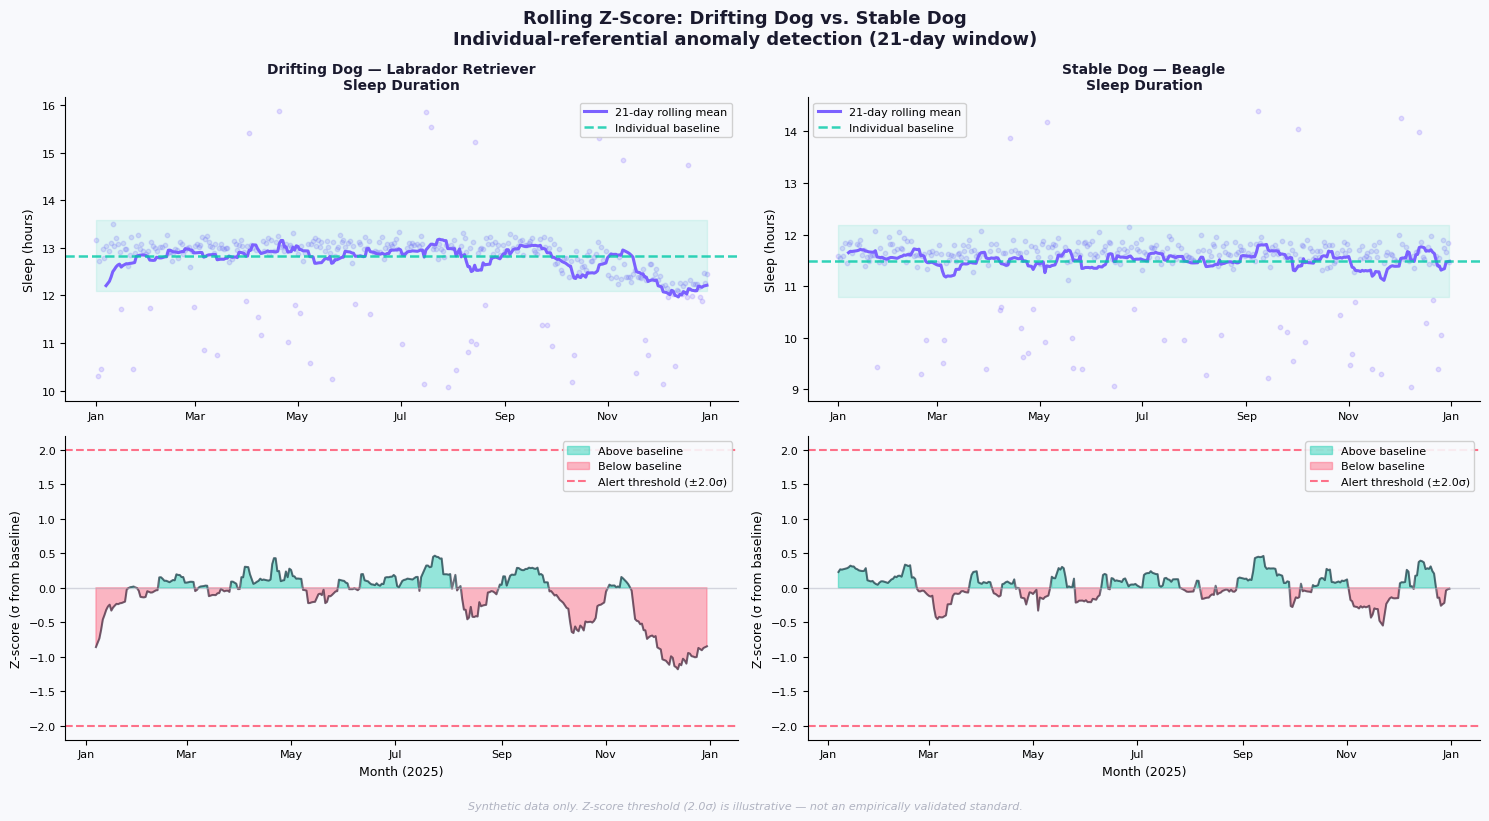

In [4]:
# ── Visualize rolling Z-score: drifting vs stable dog ─────────────────────

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle("Rolling Z-Score: Drifting Dog vs. Stable Dog\n"
             "Individual-referential anomaly detection (21-day window)",
             fontsize=13, fontweight='bold', color=COLORS['primary'])

z_threshold = 2.0  # illustrative threshold

for col_idx, (zs, label, dog_id) in enumerate([
    (zs_drift,  "Drifting Dog",  drift_dogs[0]),
    (zs_stable, "Stable Dog",    stable_dogs[0]),
]):
    breed = df[df['dog_id'] == dog_id]['breed'].iloc[0]
    
    # Top: raw signal + rolling mean + baseline
    ax_top = axes[0][col_idx]
    ax_top.set_facecolor(COLORS['bg'])
    ax_top.spines['top'].set_visible(False); ax_top.spines['right'].set_visible(False)
    
    ax_top.scatter(zs.index, zs['value'], color=COLORS['accent'], alpha=0.2, s=10)
    ax_top.plot(zs.index, zs['rolling_mean'], color=COLORS['accent'], linewidth=2.2,
                label='21-day rolling mean')
    ax_top.axhline(zs['baseline_mean'].iloc[0], color=COLORS['stable'], linewidth=1.8,
                   linestyle='--', alpha=0.8, label='Individual baseline')
    ax_top.fill_between(zs.index,
                        zs['baseline_mean'].iloc[0] - zs['baseline_std'].iloc[0],
                        zs['baseline_mean'].iloc[0] + zs['baseline_std'].iloc[0],
                        color=COLORS['stable'], alpha=0.1)
    ax_top.set_title(f"{label} — {breed}\nSleep Duration", fontsize=10,
                     fontweight='bold', color=COLORS['primary'])
    ax_top.set_ylabel("Sleep (hours)", fontsize=9)
    ax_top.legend(fontsize=8, framealpha=0.9)
    ax_top.tick_params(labelsize=8)
    ax_top.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))

    # Bottom: Z-score
    ax_bot = axes[1][col_idx]
    ax_bot.set_facecolor(COLORS['bg'])
    ax_bot.spines['top'].set_visible(False); ax_bot.spines['right'].set_visible(False)
    
    z = zs['z_score']
    alert_mask = z.abs() > z_threshold
    
    ax_bot.fill_between(z.index, 0, z, where=z >= 0,
                        color=COLORS['stable'], alpha=0.4, label='Above baseline')
    ax_bot.fill_between(z.index, 0, z, where=z < 0,
                        color=COLORS['signal'], alpha=0.4, label='Below baseline')
    ax_bot.plot(z.index, z, color=COLORS['primary'], linewidth=1.5, alpha=0.6)

    # Alert zones
    ax_bot.axhline( z_threshold, color=COLORS['signal'], linewidth=1.5,
                   linestyle='--', alpha=0.8, label=f'Alert threshold (±{z_threshold}σ)')
    ax_bot.axhline(-z_threshold, color=COLORS['signal'], linewidth=1.5, linestyle='--', alpha=0.8)
    ax_bot.axhline(0, color=COLORS['neutral'], linewidth=1, alpha=0.5)

    # Mark alert periods
    alert_dates = z[alert_mask].index
    if len(alert_dates) > 0:
        ax_bot.scatter(alert_dates, z[alert_mask], color=COLORS['signal'],
                       s=30, zorder=4, label=f'Alert ({len(alert_dates)} days)')

    ax_bot.set_ylabel("Z-score (σ from baseline)", fontsize=9)
    ax_bot.set_xlabel("Month (2025)", fontsize=9)
    ax_bot.legend(fontsize=8, framealpha=0.9)
    ax_bot.tick_params(labelsize=8)
    ax_bot.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))

fig.text(0.5, -0.02, 'Synthetic data only. Z-score threshold (2.0σ) is illustrative — not an empirically validated standard.',
         ha='center', fontsize=8, color=COLORS['neutral'], style='italic')
plt.tight_layout()
plt.savefig('../figures/rolling_zscore_drift_vs_stable.png', dpi=130,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


## 3. CUSUM: Accumulating Small Deviations Until a Pattern Emerges

The rolling Z-score is reactive — it flags when a single window is anomalous.

**CUSUM (Cumulative Sum)** is more sensitive to gradual, sustained drift. It accumulates small deviations from baseline over time. Even if no single day crosses a threshold, CUSUM detects when many consecutive days are slightly below baseline.

This makes CUSUM well-suited to the behavioral drift use case: decline is gradual, not sudden.

**CUSUM formula (one-sided, detecting downward drift):**

```
S_t = max(0, S_{t-1} - (x_t - μ_0 + k))
```

Where:
- `x_t` = today's observation
- `μ_0` = individual baseline mean
- `k` = slack parameter (half the expected shift to detect), typically 0.5σ
- `h` = detection threshold (typically 4–5σ·√n in research and industrial settings)

We use `k = 0.5` and an illustrative `h = 4.0` here.


In [5]:
# ── CUSUM implementation ──────────────────────────────────────────────────

def compute_cusum(series, baseline_mean, baseline_std, k_factor=0.5, h_factor=4.0):
    """
    Two-sided CUSUM for individual behavioral drift detection.
    
    k_factor: slack (in units of baseline_std)
    h_factor: detection threshold (in units of baseline_std)
    
    Returns:
        cusum_pos: upper CUSUM (detects upward drift)
        cusum_neg: lower CUSUM (detects downward drift — key for behavioral drift)
        alert_pos: dates where upward drift detected
        alert_neg: dates where downward drift detected
    """
    series = series.dropna()
    k = k_factor * baseline_std
    h = h_factor * baseline_std
    
    cusum_pos = np.zeros(len(series))
    cusum_neg = np.zeros(len(series))
    
    for i, x in enumerate(series.values):
        if i == 0:
            cusum_pos[i] = max(0, (x - baseline_mean) - k)
            cusum_neg[i] = max(0, -(x - baseline_mean) - k)
        else:
            cusum_pos[i] = max(0, cusum_pos[i-1] + (x - baseline_mean) - k)
            cusum_neg[i] = max(0, cusum_neg[i-1] - (x - baseline_mean) - k)
    
    cusum_s = pd.Series(cusum_pos, index=series.index)
    cusum_n = pd.Series(cusum_neg, index=series.index)
    
    alert_pos = series.index[cusum_s > h]
    alert_neg = series.index[cusum_n > h]
    
    return cusum_s, cusum_n, alert_pos, alert_neg, h

# Apply to drifting dog — sleep hours
dog = df[df['dog_id'] == drift_dogs[2]].set_index('date')
dog_obs = dog[~dog['data_missing']]['sleep_hours'].sort_index().dropna()

# Baseline from months 1-5
baseline_cutoff = dog_obs.index[0] + pd.Timedelta(days=150)
baseline_data   = dog_obs[dog_obs.index < baseline_cutoff]
b_mean, b_std   = baseline_data.mean(), baseline_data.std()

print(f"Dog: {drift_dogs[2]} | Breed: {dog['breed'].iloc[0]}")
print(f"Individual baseline: {b_mean:.2f}h ± {b_std:.2f}h")

cusum_pos, cusum_neg, alert_pos, alert_neg, h = compute_cusum(dog_obs, b_mean, b_std)

print(f"\nCUSUM detection threshold h: {h:.3f}")
print(f"Upward drift alerts:   {len(alert_pos)} days")
print(f"Downward drift alerts: {len(alert_neg)} days")
if len(alert_neg) > 0:
    print(f"First downward alert detected: {alert_neg[0].date()}")


Dog: DOG_0013 | Breed: Labrador Retriever
Individual baseline: 11.78h ± 0.84h

CUSUM detection threshold h: 3.348
Upward drift alerts:   2 days
Downward drift alerts: 69 days
First downward alert detected: 2025-02-28


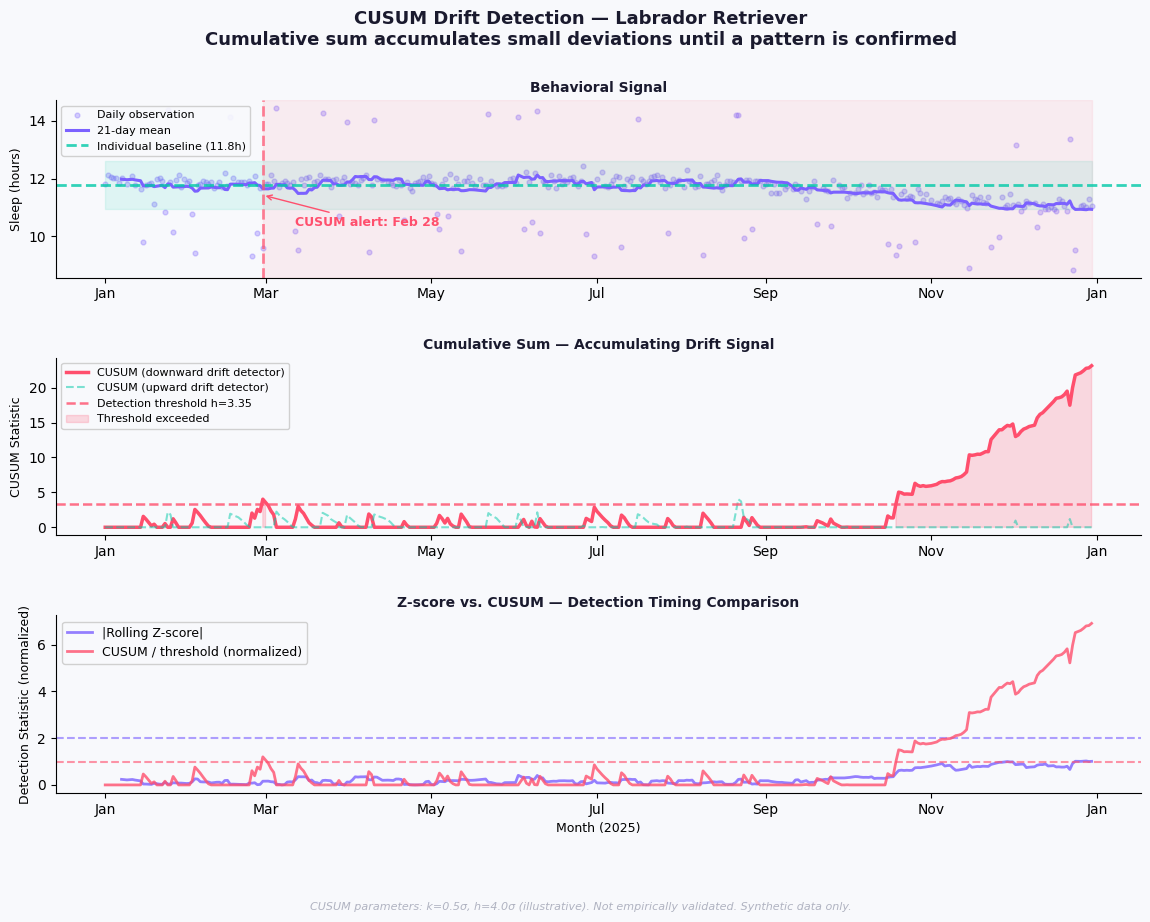

In [6]:
# ── CUSUM visualization ────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)
fig.patch.set_facecolor(COLORS['bg'])

breed = dog['breed'].iloc[0]
fig.suptitle(f"CUSUM Drift Detection — {breed}\n"
             "Cumulative sum accumulates small deviations until a pattern is confirmed",
             fontsize=13, fontweight='bold', color=COLORS['primary'])

# ── Panel 1: raw signal ──
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(COLORS['bg'])
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax1.scatter(dog_obs.index, dog_obs.values, color=COLORS['accent'],
            alpha=0.3, s=12, label='Daily observation')
rolling21 = dog_obs.rolling('21D', min_periods=7).mean()
ax1.plot(rolling21.index, rolling21.values, color=COLORS['accent'], linewidth=2.2, label='21-day mean')
ax1.axhline(b_mean, color=COLORS['stable'], linewidth=2, linestyle='--',
            alpha=0.8, label=f'Individual baseline ({b_mean:.1f}h)')
ax1.fill_between(dog_obs.index, b_mean - b_std, b_mean + b_std,
                 color=COLORS['stable'], alpha=0.1)

# Shade CUSUM alert period
if len(alert_neg) > 0:
    ax1.axvspan(alert_neg[0], dog_obs.index[-1], color=COLORS['signal'], alpha=0.08)
    ax1.axvline(alert_neg[0], color=COLORS['signal'], linewidth=2, linestyle='--', alpha=0.7)
    ax1.annotate(f"CUSUM alert: {alert_neg[0].strftime('%b %d')}",
                xy=(alert_neg[0], b_mean * 0.97), xytext=(alert_neg[0] + pd.Timedelta(days=12), b_mean * 0.88),
                fontsize=9, color=COLORS['signal'], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=COLORS['signal']))

ax1.set_ylabel('Sleep (hours)', fontsize=9)
ax1.set_title('Behavioral Signal', fontsize=10, fontweight='bold', color=COLORS['primary'])
ax1.legend(fontsize=8, framealpha=0.9)
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))

# ── Panel 2: CUSUM statistic ──
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(COLORS['bg'])
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

ax2.plot(cusum_neg.index, cusum_neg.values, color=COLORS['signal'], linewidth=2.5,
         label='CUSUM (downward drift detector)')
ax2.plot(cusum_pos.index, cusum_pos.values, color=COLORS['stable'], linewidth=1.5,
         alpha=0.5, label='CUSUM (upward drift detector)', linestyle='--')
ax2.axhline(h, color=COLORS['signal'], linewidth=1.8, linestyle='--',
            alpha=0.8, label=f'Detection threshold h={h:.2f}')
ax2.fill_between(cusum_neg.index, 0, cusum_neg.values,
                 where=cusum_neg.values > h, color=COLORS['signal'], alpha=0.2,
                 label='Threshold exceeded')

ax2.set_ylabel('CUSUM Statistic', fontsize=9)
ax2.set_title('Cumulative Sum — Accumulating Drift Signal', fontsize=10,
              fontweight='bold', color=COLORS['primary'])
ax2.legend(fontsize=8, framealpha=0.9)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))

# ── Panel 3: CUSUM advantage — early detection vs threshold crossing ──
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(COLORS['bg'])
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# Rolling Z-score for same dog
zs = compute_rolling_zscore(dog_obs)
z_alert_days = zs['z_score'][zs['z_score'].abs() > 2.0]

ax3.plot(zs.index, zs['z_score'].abs(), color=COLORS['accent'], linewidth=2,
         label='|Rolling Z-score|', alpha=0.8)
ax3.axhline(2.0, color=COLORS['accent'], linewidth=1.5, linestyle='--', alpha=0.6)

# Normalize CUSUM to compare
cusum_norm = cusum_neg / h
ax3.plot(cusum_norm.index, cusum_norm.values, color=COLORS['signal'], linewidth=2,
         label='CUSUM / threshold (normalized)', alpha=0.8)
ax3.axhline(1.0, color=COLORS['signal'], linewidth=1.5, linestyle='--', alpha=0.6)

ax3.set_ylabel('Detection Statistic (normalized)', fontsize=9)
ax3.set_xlabel('Month (2025)', fontsize=9)
ax3.set_title('Z-score vs. CUSUM — Detection Timing Comparison', fontsize=10,
              fontweight='bold', color=COLORS['primary'])
ax3.legend(fontsize=9, framealpha=0.9)
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))

fig.text(0.5, -0.02,
         'CUSUM parameters: k=0.5σ, h=4.0σ (illustrative). Not empirically validated. Synthetic data only.',
         ha='center', fontsize=8, color=COLORS['neutral'], style='italic')

plt.savefig('../figures/cusum_drift_detection.png', dpi=130,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


## 4. Multi-Signal Drift Score

Sleep alone is one signal. Cognitive drift — if it occurs — tends to manifest across multiple behavioral dimensions simultaneously.

The Barkley framework models **four cognitive dimensions**, drawing on Duke Canine Cognition Center research (Gnanadesikan et al., 2020):
- Inhibitory control → proxied by activity patterns
- Communication → proxied by social interaction score
- Memory/attention → proxied by vocalization consistency
- Physical coordination → proxied by nocturnal restlessness

We combine Z-scores across signals into a **composite drift index**, weighted equally here. In a production system, signal weights would be calibrated against longitudinal behavioral data.

This is demonstrative. Combining noisy signals amplifies the drift signature while reducing false alerts from single-signal noise.


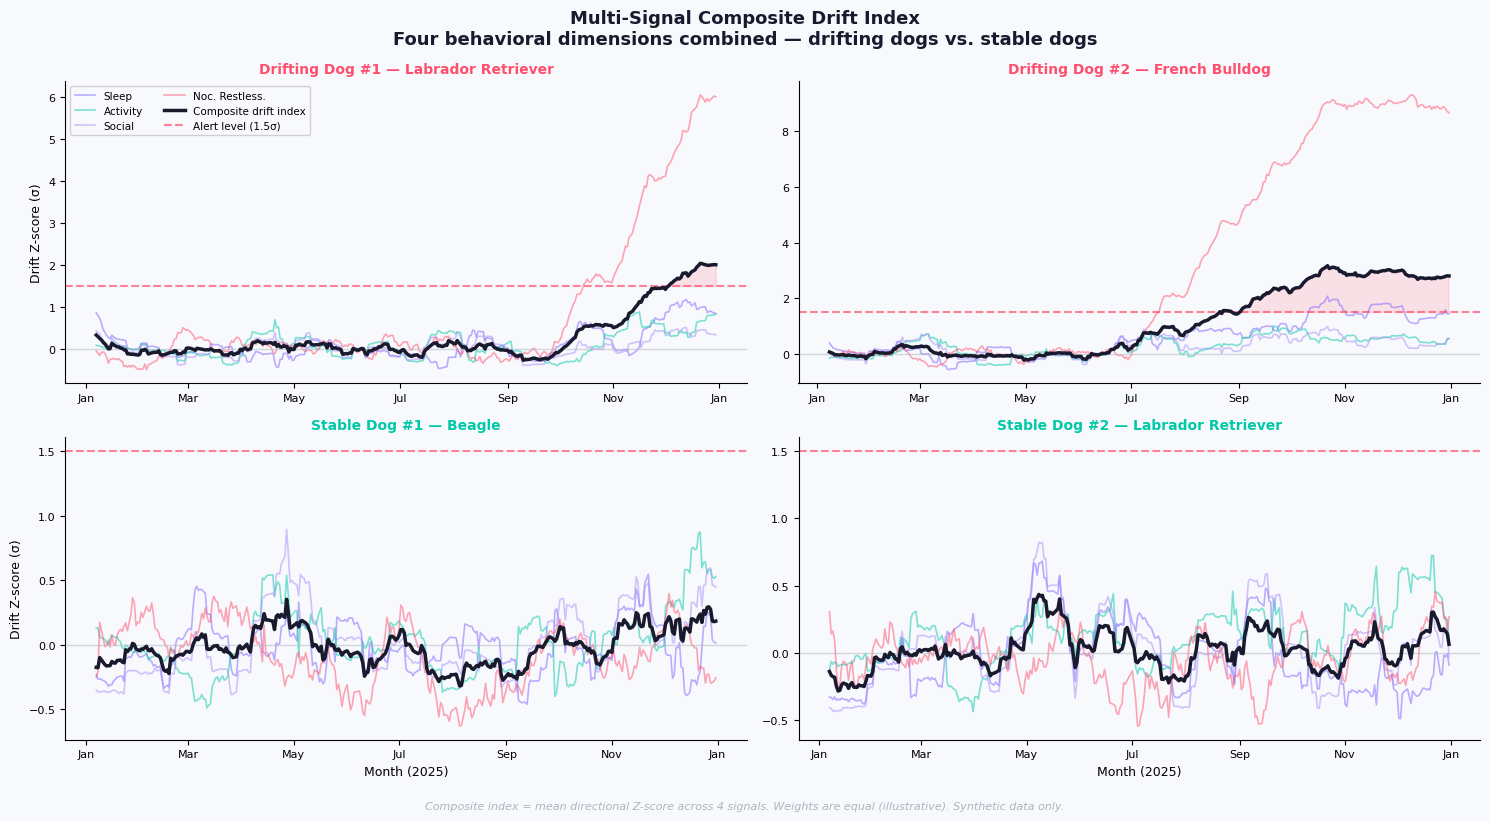

In [7]:
# ── Multi-signal composite drift index ────────────────────────────────────

SIGNALS = {
    'sleep_hours':            {'direction': -1, 'label': 'Sleep',          'color': COLORS['accent']},
    'activity_minutes':       {'direction': -1, 'label': 'Activity',        'color': COLORS['stable']},
    'social_score':           {'direction': -1, 'label': 'Social',          'color': '#A78BFA'},
    'nocturnal_restlessness': {'direction':  1, 'label': 'Noc. Restless.', 'color': COLORS['signal']},
}
# direction: -1 = decrease is concerning, +1 = increase is concerning

def compute_composite_drift(dog_id, df, baseline_days=150, rolling_w=21):
    dog = df[df['dog_id'] == dog_id].set_index('date')
    dog_obs = dog[~dog['data_missing']].sort_index()
    
    baseline_cutoff = dog_obs.index[0] + pd.Timedelta(days=baseline_days)
    
    z_scores = {}
    for sig, props in SIGNALS.items():
        series = dog_obs[sig].dropna()
        if len(series) < 30:
            continue
        
        baseline = series[series.index < baseline_cutoff]
        b_mean, b_std = baseline.mean(), max(baseline.std(), 0.01)
        
        rolling_mean = series.rolling(f'{rolling_w}D', min_periods=7).mean()
        z = (rolling_mean - b_mean) / b_std * props['direction']  # positive = concerning
        z_scores[sig] = z
    
    z_df = pd.DataFrame(z_scores)
    
    # Composite: mean of directional Z-scores across available signals
    composite = z_df.mean(axis=1)
    return z_df, composite

# Compare drifting vs stable cohort
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle("Multi-Signal Composite Drift Index\n"
             "Four behavioral dimensions combined — drifting dogs vs. stable dogs",
             fontsize=13, fontweight='bold', color=COLORS['primary'])

sample_drifters = drift_dogs[:4]
sample_stables  = stable_dogs[:4]

for row_idx, (dog_group, group_label) in enumerate([
    (sample_drifters, "Drifting Dog"),
    (sample_stables,  "Stable Dog"),
]):
    for col_idx, dog_id in enumerate(dog_group[:2]):
        ax = axes[row_idx][col_idx]
        ax.set_facecolor(COLORS['bg'])
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        
        z_df, composite = compute_composite_drift(dog_id, df)
        breed = df[df['dog_id'] == dog_id]['breed'].iloc[0]
        
        for sig, props in SIGNALS.items():
            if sig in z_df.columns:
                ax.plot(z_df.index, z_df[sig], color=props['color'],
                        linewidth=1.2, alpha=0.5, label=props['label'])
        
        ax.plot(composite.index, composite.values, color=COLORS['primary'],
                linewidth=2.5, label='Composite drift index', zorder=4)
        ax.axhline(0, color=COLORS['neutral'], linewidth=1, alpha=0.5)
        ax.axhline(1.5, color=COLORS['signal'], linewidth=1.5,
                   linestyle='--', alpha=0.7, label='Alert level (1.5σ)' if col_idx == 0 else '')
        
        # Shade above threshold
        ax.fill_between(composite.index, 1.5, composite.values,
                        where=composite.values > 1.5,
                        color=COLORS['signal'], alpha=0.15)
        
        title_color = COLORS['signal'] if group_label == "Drifting Dog" else COLORS['stable']
        ax.set_title(f"{group_label} #{col_idx+1} — {breed}",
                     fontsize=10, fontweight='bold', color=title_color)
        ax.set_ylabel("Drift Z-score (σ)" if col_idx == 0 else '', fontsize=9)
        ax.set_xlabel("Month (2025)" if row_idx == 1 else '', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7.5, framealpha=0.9, ncol=2)

fig.text(0.5, -0.02,
         'Composite index = mean directional Z-score across 4 signals. Weights are equal (illustrative). '
         'Synthetic data only.',
         ha='center', fontsize=8, color=COLORS['neutral'], style='italic')
plt.tight_layout()
plt.savefig('../figures/composite_drift_index.png', dpi=130,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


## 5. Cohort View: Drift Signatures Across the Full Population

Finally, let's step back to the cohort level: what does the drift index distribution look like across all 100 dogs at the end of the observation period?

This visualizes the separation between drifting and stable dogs — and the degree of overlap.


Cohort drift scores computed for 100 dogs

Drift score statistics:
           count   mean    std    min    25%    50%    75%    max
has_drift                                                        
False       81.0  0.026  0.095 -0.165 -0.038  0.035  0.089  0.290
True        19.0  2.795  1.006  1.459  1.979  2.849  3.238  4.909


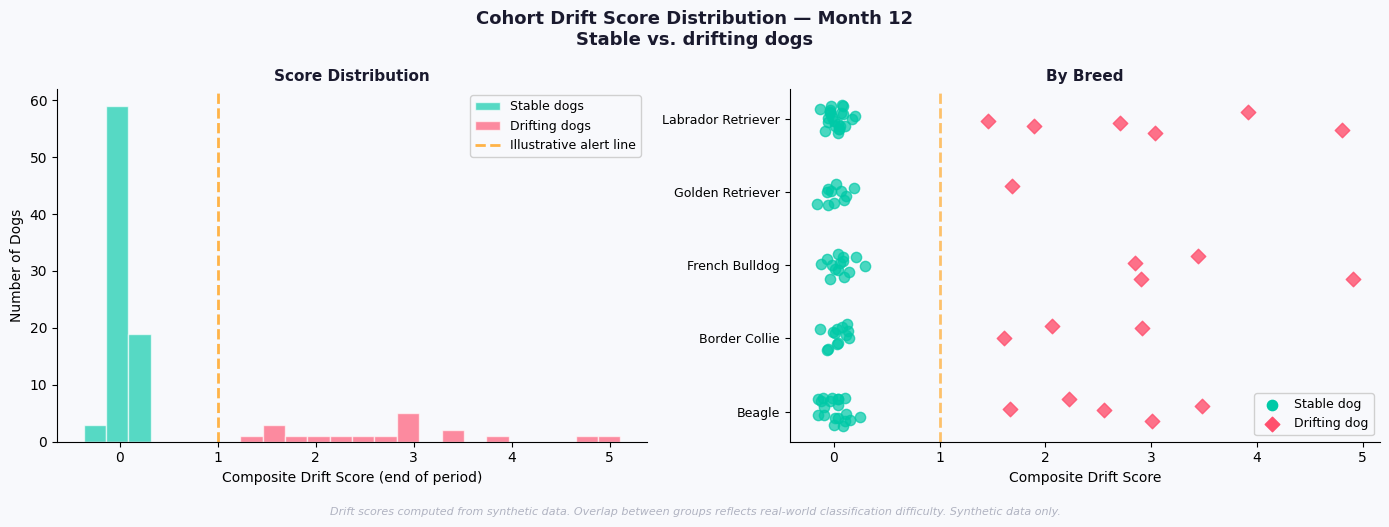

In [8]:
# ── Cohort drift scores at month 12 ──────────────────────────────────────

all_dogs = df['dog_id'].unique()
end_scores = []

for dog_id in all_dogs:
    try:
        _, composite = compute_composite_drift(dog_id, df)
        # Score = mean composite drift in last 60 days
        recent = composite[composite.index >= pd.Timestamp('2025-11-01')]
        if len(recent) >= 10:
            score = recent.mean()
            has_drift = df[df['dog_id'] == dog_id]['has_drift'].iloc[0]
            breed = df[df['dog_id'] == dog_id]['breed'].iloc[0]
            end_scores.append({'dog_id': dog_id, 'drift_score': score,
                               'has_drift': has_drift, 'breed': breed})
    except Exception:
        pass

scores_df = pd.DataFrame(end_scores)
print(f"Cohort drift scores computed for {len(scores_df)} dogs")
print(f"\nDrift score statistics:")
print(scores_df.groupby('has_drift')['drift_score'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cohort Drift Score Distribution — Month 12\n"
             "Stable vs. drifting dogs",
             fontsize=13, fontweight='bold', color=COLORS['primary'])

# Left: histogram
ax = axes[0]
ax.set_facecolor(COLORS['bg'])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

stable_scores  = scores_df[~scores_df['has_drift']]['drift_score']
drifting_scores = scores_df[scores_df['has_drift']]['drift_score']

bins = np.linspace(scores_df['drift_score'].min() - 0.2, scores_df['drift_score'].max() + 0.2, 25)
ax.hist(stable_scores,  bins=bins, color=COLORS['stable'], alpha=0.65, label='Stable dogs',  edgecolor='white')
ax.hist(drifting_scores, bins=bins, color=COLORS['signal'], alpha=0.65, label='Drifting dogs', edgecolor='white')
ax.axvline(1.0, color=COLORS['warn'], linewidth=2, linestyle='--', label='Illustrative alert line')
ax.set_xlabel('Composite Drift Score (end of period)', fontsize=10)
ax.set_ylabel('Number of Dogs', fontsize=10)
ax.set_title('Score Distribution', fontsize=11, fontweight='bold', color=COLORS['primary'])
ax.legend(fontsize=9, framealpha=0.9)

# Right: dot plot by breed
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg'])
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

breeds_sorted = sorted(scores_df['breed'].unique())
for i, breed in enumerate(breeds_sorted):
    grp = scores_df[scores_df['breed'] == breed]
    stable_b  = grp[~grp['has_drift']]['drift_score']
    drifting_b = grp[grp['has_drift']]['drift_score']
    
    jitter_s = np.random.uniform(-0.2, 0.2, len(stable_b))
    jitter_d = np.random.uniform(-0.2, 0.2, len(drifting_b))
    
    ax2.scatter(stable_b,  np.full(len(stable_b),  i) + jitter_s,
                color=COLORS['stable'], s=55, alpha=0.7)
    ax2.scatter(drifting_b, np.full(len(drifting_b), i) + jitter_d,
                color=COLORS['signal'], s=55, alpha=0.8, marker='D')

ax2.axvline(1.0, color=COLORS['warn'], linewidth=2, linestyle='--', alpha=0.8)
ax2.set_yticks(range(len(breeds_sorted)))
ax2.set_yticklabels(breeds_sorted, fontsize=9)
ax2.set_xlabel('Composite Drift Score', fontsize=10)
ax2.set_title('By Breed', fontsize=11, fontweight='bold', color=COLORS['primary'])

legend_els = [
    plt.scatter([], [], color=COLORS['stable'], s=55, label='Stable dog'),
    plt.scatter([], [], color=COLORS['signal'], s=55, marker='D', label='Drifting dog'),
]
ax2.legend(handles=legend_els, fontsize=9, framealpha=0.9)

fig.text(0.5, -0.03,
         'Drift scores computed from synthetic data. '
         'Overlap between groups reflects real-world classification difficulty. Synthetic data only.',
         ha='center', fontsize=8, color=COLORS['neutral'], style='italic')
plt.tight_layout()
plt.savefig('../figures/cohort_drift_scores.png', dpi=130,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


## Summary

This notebook demonstrated three complementary temporal drift detection approaches:

| Method | Sensitivity | Interpretability | Best for |
|--------|-------------|-----------------|----------|
| Rolling Z-score | Moderate | High | Day-level anomaly flagging |
| CUSUM | High (gradual drift) | Medium | Sustained directional change |
| Composite drift index | High | Medium | Multi-signal convergence |

### Key Observations (Synthetic Data)

- Single-signal Z-scores catch obvious anomalies but miss gradual drift
- CUSUM accumulates small deviations and detects sustained change earlier
- Multi-signal composite reduces false alerts while amplifying genuine drift signatures
- Cohort-level distributions show meaningful separation — with real-world overlap

### What This Means for Barkley

Individual temporal modeling transforms behavioral data from a **warehouse** into an **intelligence layer**. The same data, analyzed with temporal methods rather than population comparisons, yields qualitatively different behavioral signal.

---

> **Next:** Notebook 03 explores the Missing Data Paradox — what the absence of data tells us.
